In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.ensemble import ExtraTreesClassifier as SKExtraTreesClassifier, ExtraTreesRegressor as SKExtraTreesRegressor

from cart import DecisionTreeClassifier
from extra_tree import ExtraTreeClassifier, ExtraTreesClassifier, ExtraTreeRegressor, ExtraTreesRegressor

CLASS_COLORS = ["b", "g", "y"]

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [2]:
single = ExtraTreeClassifier(max_depth=4, max_features=2, random_state=42).fit(X_train, y_train)
forest = ExtraTreesClassifier(n_estimators=100, max_depth=4, max_features=2, random_state=42).fit(X_train, y_train)
sk_forest = SKExtraTreesClassifier(n_estimators=100, max_depth=4, max_features=2, random_state=42).fit(X_train, y_train)

for name, model in [("single tree", single), ("extra trees (custom)", forest), ("extra trees (sklearn)", sk_forest)]:
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, np.ravel(preds))
    print(f"{name:>22}: test accuracy = {acc:.3f}")

           single tree: test accuracy = 0.947
  extra trees (custom): test accuracy = 0.921
 extra trees (sklearn): test accuracy = 0.921


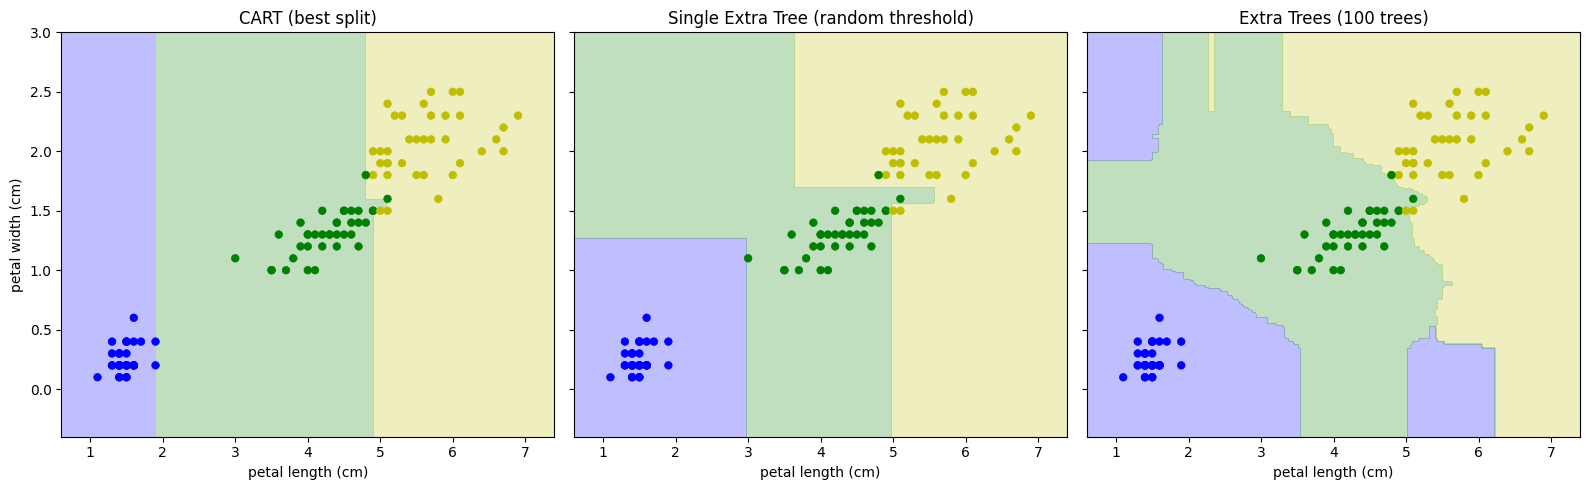

In [3]:
feat_x, feat_y = 2, 3  # petal length, petal width
X2_train = X_train[:, [feat_x, feat_y]]

cart_tree = DecisionTreeClassifier(max_depth=6, random_state=42)
cart_tree.fit(X2_train, y_train)
extra_single = ExtraTreeClassifier(max_depth=6, max_features=2, random_state=42).fit(X2_train, y_train)
extra_forest = ExtraTreesClassifier(n_estimators=100, max_depth=6, max_features=2, random_state=42).fit(X2_train, y_train)

pad = 0.5
x_min, x_max = X2_train[:, 0].min() - pad, X2_train[:, 0].max() + pad
y_min, y_max = X2_train[:, 1].min() - pad, X2_train[:, 1].max() + pad
xv, yv = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xv.ravel(), yv.ravel()]

models = [
    ("CART (best split)", cart_tree),
    ("Single Extra Tree (random threshold)", extra_single),
    ("Extra Trees (100 trees)", extra_forest),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, (title, model) in zip(axes, models):
    Z = np.ravel(model.predict(grid)).reshape(xv.shape)
    ax.contourf(xv, yv, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=CLASS_COLORS, alpha=0.25)
    ax.scatter(
        X2_train[:, 0], X2_train[:, 1],
        c=[CLASS_COLORS[c] for c in y_train],
        linewidth=0.5, s=30, zorder=3,
    )
    ax.set_title(title)
    ax.set_xlabel(iris.feature_names[feat_x])

axes[0].set_ylabel(iris.feature_names[feat_y])
plt.tight_layout()
plt.show()

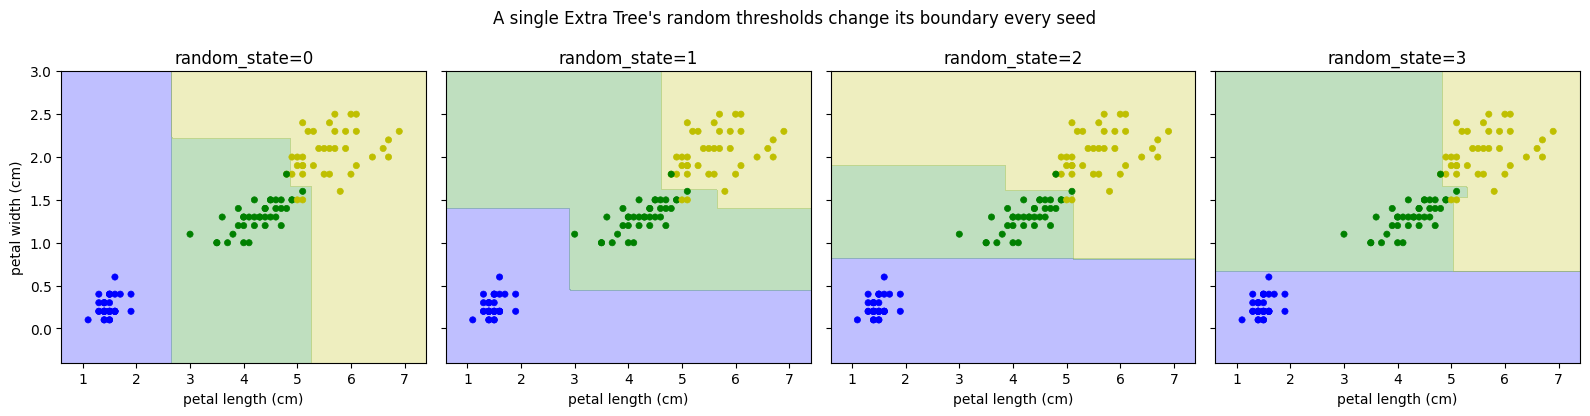

In [4]:
# A single Extra Tree picks one *random* threshold per candidate feature instead of the
# best one, so its boundary is unstable across seeds. Averaging many of these random
# trees (above) is what pulls the ensemble boundary back towards something sensible.
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharex=True, sharey=True)
for ax, seed in zip(axes, [0, 1, 2, 3]):
    tree = ExtraTreeClassifier(max_depth=6, max_features=2, random_state=seed).fit(X2_train, y_train)
    Z = np.ravel(tree.predict(grid)).reshape(xv.shape)
    ax.contourf(xv, yv, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=CLASS_COLORS, alpha=0.25)
    ax.scatter(
        X2_train[:, 0], X2_train[:, 1],
        c=[CLASS_COLORS[c] for c in y_train],
        linewidth=0.5, s=20, zorder=3,
    )
    ax.set_title(f"random_state={seed}")
    ax.set_xlabel(iris.feature_names[feat_x])

axes[0].set_ylabel(iris.feature_names[feat_y])
fig.suptitle("A single Extra Tree's random thresholds change its boundary every seed")
plt.tight_layout()
plt.show()

In [5]:
rng = np.random.default_rng(42)
X_reg = np.sort(rng.uniform(0, 10, 200)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + rng.normal(0, 0.15, X_reg.shape[0])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

single_reg = ExtraTreeRegressor(max_depth=5, max_features=1, random_state=42).fit(Xr_train, yr_train)
forest_reg = ExtraTreesRegressor(n_estimators=100, max_depth=5, max_features=1, random_state=42).fit(Xr_train, yr_train)
sk_forest_reg = SKExtraTreesRegressor(n_estimators=100, max_depth=5, max_features=1, random_state=42).fit(Xr_train, yr_train)

for name, model in [("single tree", single_reg), ("extra trees (custom)", forest_reg), ("extra trees (sklearn)", sk_forest_reg)]:
    preds = model.predict(Xr_test)
    mse = mean_squared_error(yr_test, preds)
    r2 = r2_score(yr_test, preds)
    print(f"{name:>22}: MSE={mse:.3f}  R2={r2:.3f}")

           single tree: MSE=0.052  R2=0.878
  extra trees (custom): MSE=0.027  R2=0.938
 extra trees (sklearn): MSE=0.028  R2=0.935


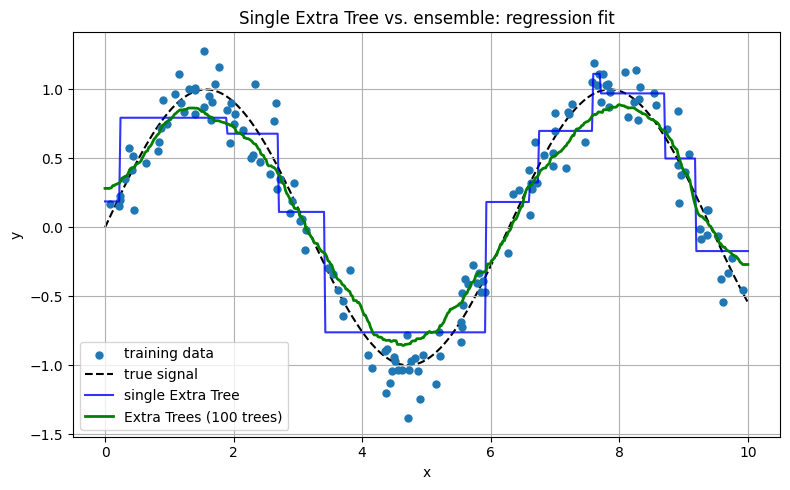

In [6]:
x_grid = np.linspace(0, 10, 500).reshape(-1, 1)
y_true = np.sin(x_grid).ravel()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    Xr_train, yr_train,
    s=25, zorder=2, label="training data",
)
ax.plot(x_grid, y_true, color="k", linestyle="--", linewidth=1.5, label="true signal", zorder=1)
ax.plot(x_grid, single_reg.predict(x_grid), color="b", linewidth=1.5, alpha=0.8, label="single Extra Tree", zorder=3)
ax.plot(x_grid, forest_reg.predict(x_grid), color="g", linewidth=2, label="Extra Trees (100 trees)", zorder=3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Single Extra Tree vs. ensemble: regression fit")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()